# Explore Netflix Data with PyGWalker

Netflix stands out as a premier platform for movies and TV shows. With an ever-growing library, understanding the trends and patterns of its content becomes crucial for analysts, filmmakers, and even viewers. In this notebook, we'll dive deep into the Netflix dataset using the PyGWalker library, a powerful tool for data visualization and exploration.

## About PyGWalker:

[PyGWalker](https://github.com/Kanaries/pygwalker) is a Python library designed to simplify the process of data visualization. It allows users to create interactive charts with minimal code, making it easier to uncover insights and patterns in datasets.

[![PyGWalker](https://user-images.githubusercontent.com/8137814/221879671-70379d15-81ac-44b9-b267-a8fa3842a0d9.png)](https://github.com/Kanaries/pygwalker)

Using PyGWalker,we can generate insightful visualizations that provide a clearer understanding of the Netflix content landscape.


## Setting Up the Environment

To kick things off, we need to ensure our environment is primed for the analysis. This involves installing the PyGWalker library and importing the necessary Python packages.


In [1]:
!pip install pygwalker -q --pre

In [2]:
import pandas as pd
import pygwalker as pyg

In [3]:
df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

## Data Loading and Preprocessing

Our first task is to load the Netflix dataset. Once loaded, we'll preprocess it to make our subsequent analysis smoother. This preprocessing involves:

- Converting the date_added column to a datetime format.
- Extracting the year and month from the date_added column.
- Cleaning up the duration column to represent either the total minutes for movies or the number of seasons for TV shows.
- Filtering out data post-2019.

In [4]:
df["date_added"] = pd.to_datetime(df["date_added"])
df["date_added_year"] = df["date_added"].dt.year.fillna(0).astype(int)
df["date_added_month"] = df["date_added"].dt.month.fillna(0).astype(int)
df["duration"] = df["duration"].fillna("0").str.split(" ").str[0].astype(int)
df = df[df["date_added_year"] <= 2019]

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_year,date_added_month
3077,s3078,Movie,Aaviri,Ravi Babu,"Ravi Babu, Neha Chauhan, Sri Muktha, Bharani S...",India,2019-12-31,2019,TV-14,110,"Horror Movies, International Movies, Thrillers","After losing their first child in an accident,...",2019,12
3078,s3079,Movie,Albert Pinto Ko Gussa Kyun Aata Hai?,Soumitra Ranade,"Nandita Das, Manav Kaul, Saurabh Shukla, Kisho...",India,2019-12-31,2019,TV-MA,85,"Dramas, Independent Movies, International Movies","As the police investigate his disappearance, a...",2019,12
3079,s3080,TV Show,ARASHI's Diary -Voyage-,NaN,Arashi,Japan,2019-12-31,2019,TV-PG,1,"Docuseries, International TV Shows","Twenty years after their debut, join the belov...",2019,12
3080,s3081,Movie,Benchwarmers 2: Breaking Balls,Jon Rosenbaum,"Chris Klein, Jon Lovitz, Chelsey Reist, Lochly...",United States,2019-12-31,2019,PG-13,90,"Comedies, Sports Movies",A rookie lawyer with an emasculating past in b...,2019,12
3081,s3082,Movie,How High 2,Bruce Leddy,"Lil Yachty, D.C. Young Fly, Alyssa Goss, DeRay...",United States,2019-12-31,2019,TV-MA,89,Comedies,"When a pair of friends uncover a weed Bible, t...",2019,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016,3
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11


## Dataset Overview

After the above preprocessing, our dataset df provides a comprehensive view of the Netflix titles. It contains information such as the type of content (movie or TV show), title, director, cast, country of production, date added to Netflix, release year, rating, duration, genre, and a brief description.

This dataset offers a snapshot of Netflix's content landscape up to the year 2019, allowing us to analyze trends, preferences, and growth patterns over the years. Take a look at the following columns:

- `show_id`: Unique ID for every Movie/TV Show
- `type`: Identifier for Movie or TV Show
- `title`: Title of the Movie/TV Show
- `director`: Director of the Movie
- `cast`: Actors involved in the movie/show
- `country`: Country where the movie/show was produced
- `date_added`: Date it was added on Netflix
- `release_year`: Actual release year of the movie/show
- `rating`: TV Rating of the movie/show
- `duration`: Total Duration - in minutes or number of seasons
- `listed_in`: Genre
- `description`: A brief description of the movie/show


## Visualize Dataset with PyGWalker

Now, for the exciting part: visualizations. With PyGWalker, we'll generate interactive visualizations to unearth insights from our dataset.

### 1. General Overview

Here, we're initializing a walker for our main dataset. This will allow us to generate a series of charts based on the specifications saved in "0.json".

Box(children=(HTML(value='<div id="ifr-pyg-0" style="height: auto">\n    <head>\n        <meta http-equiv="Con…


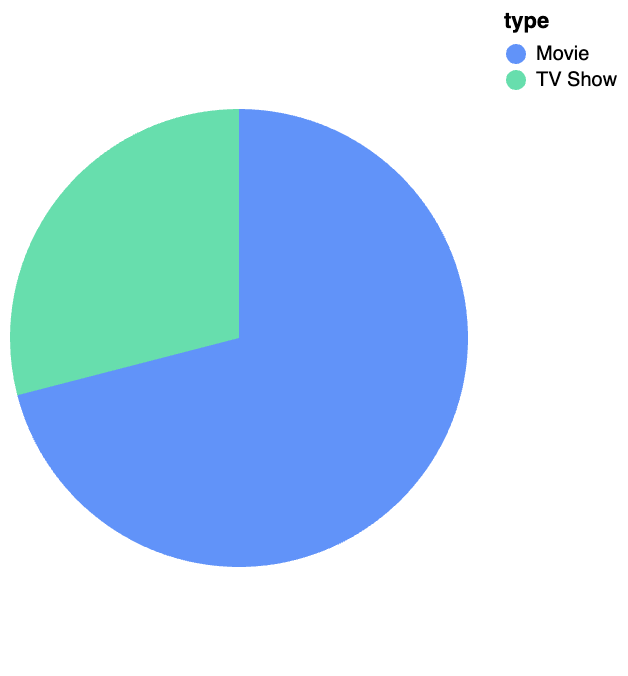
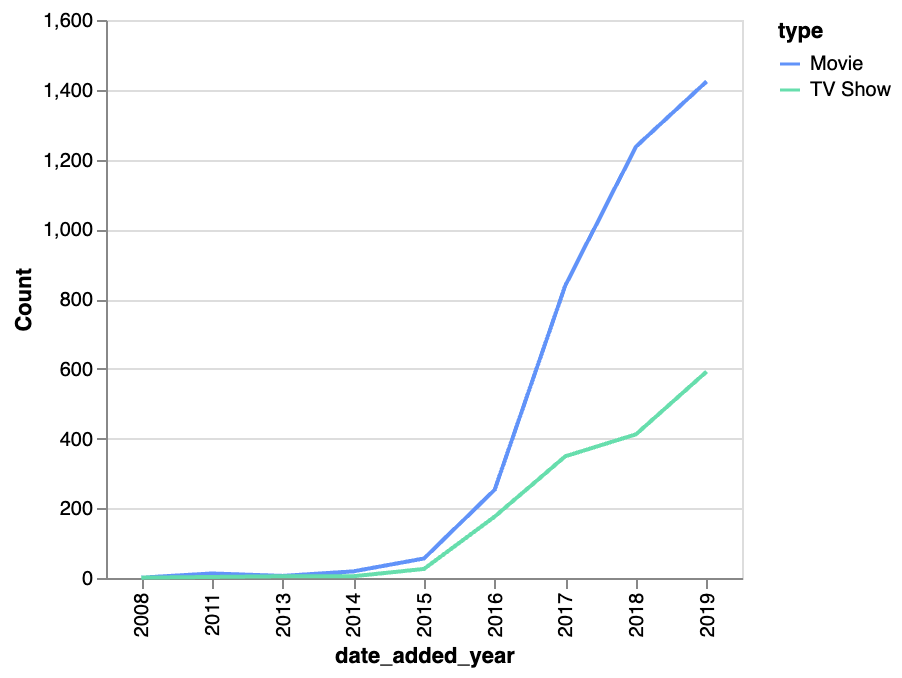
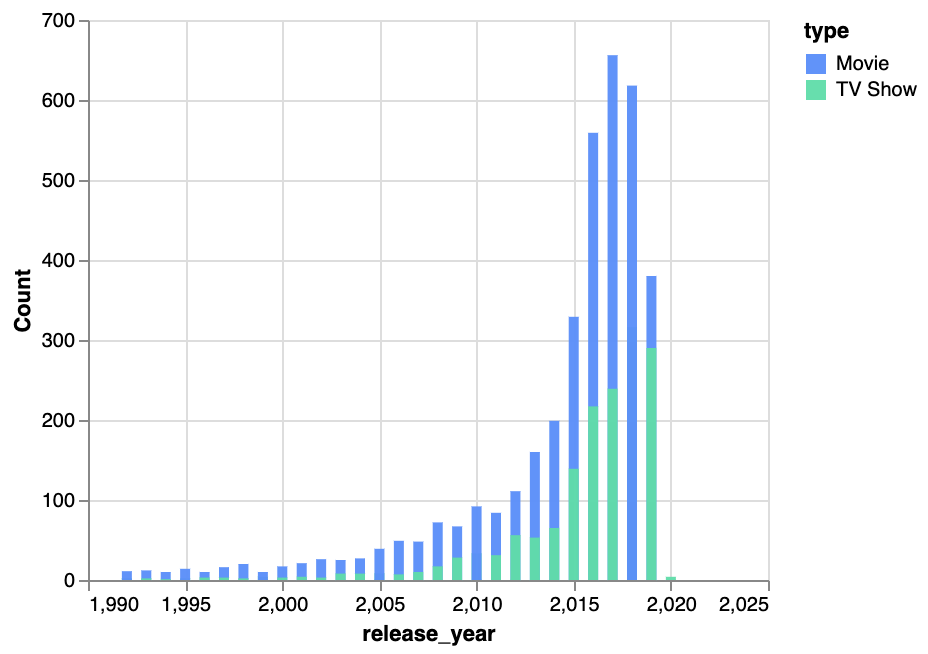
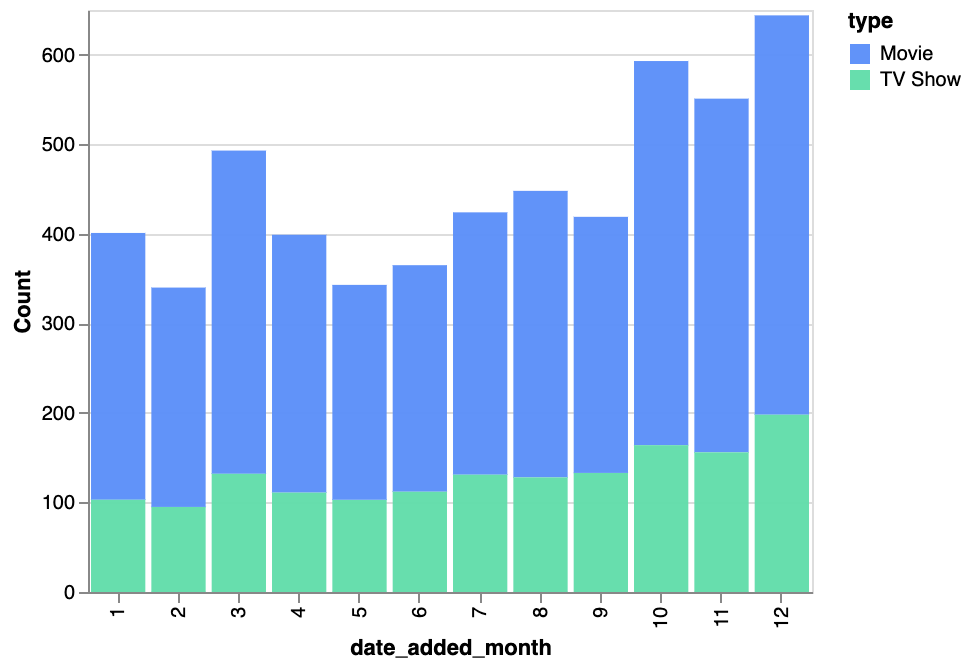
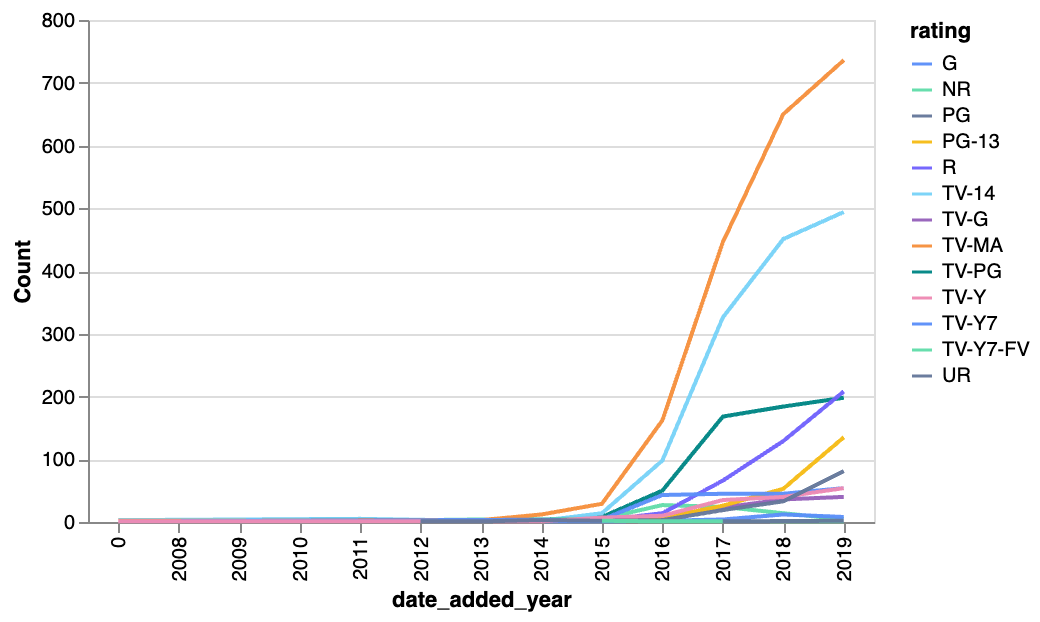
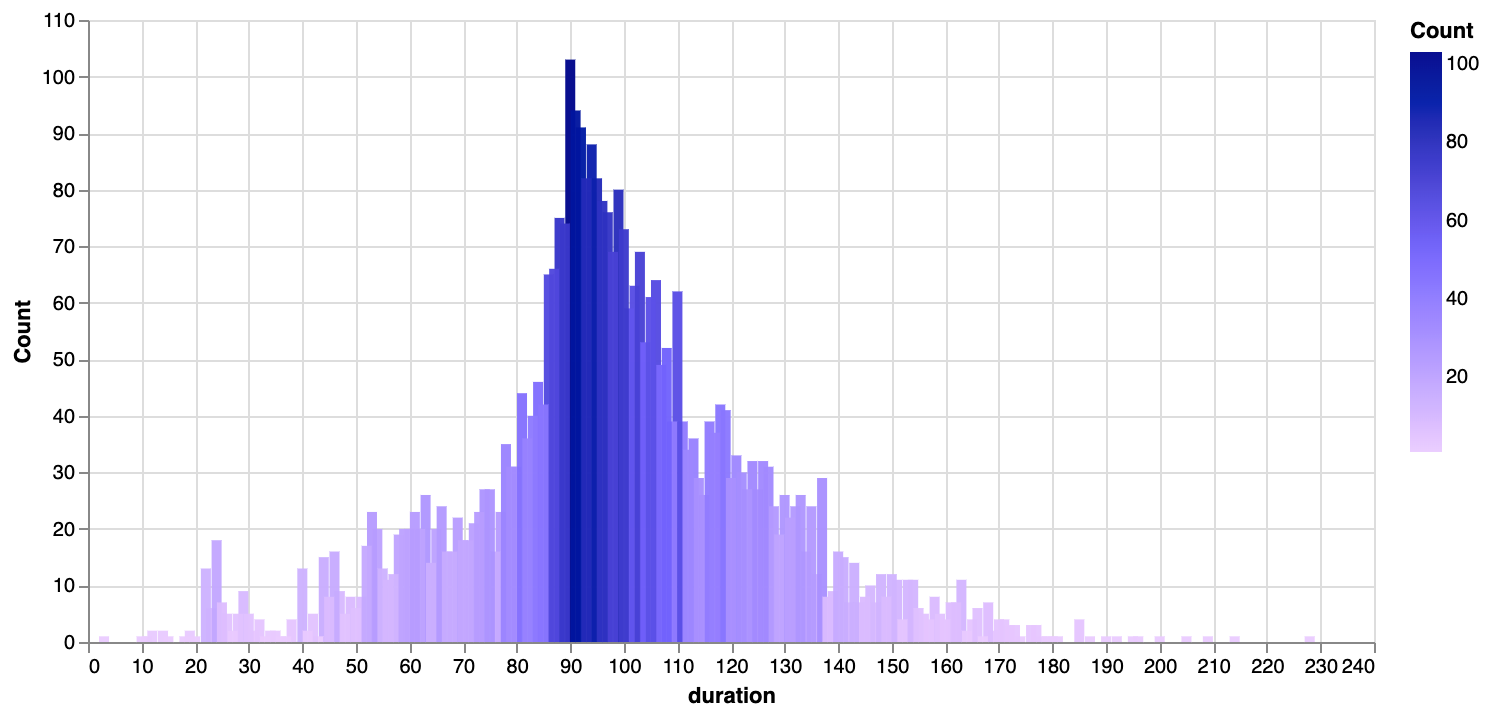
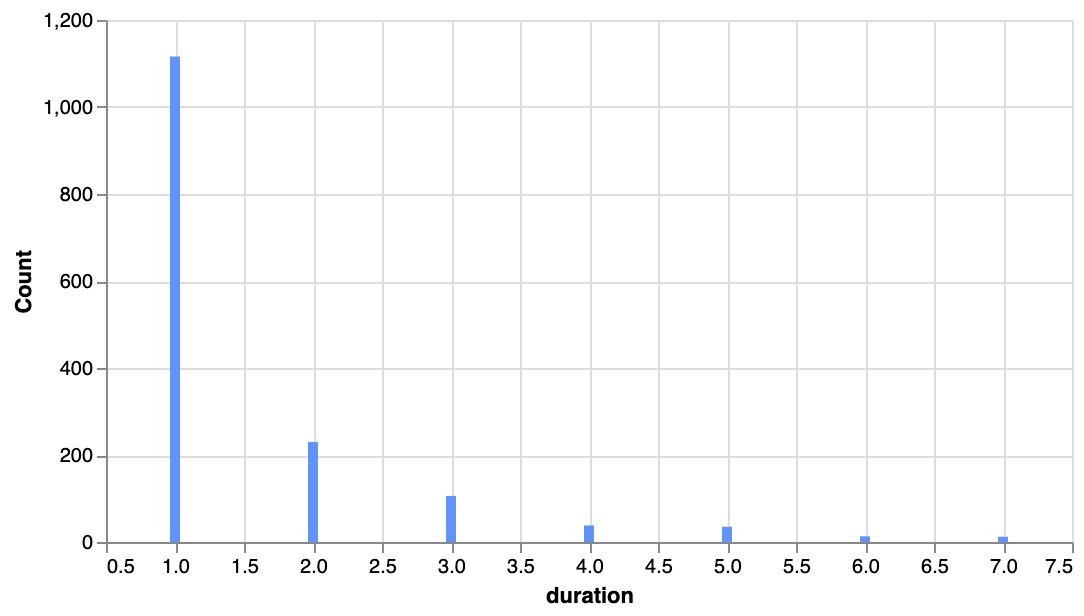
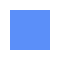

In [5]:
walker0 = pyg.walk(df, spec="0.json", use_preview=True)


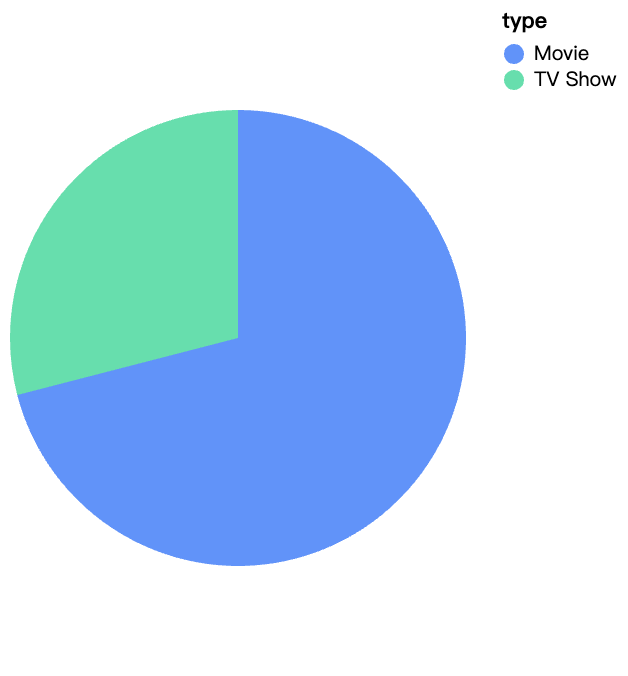

In [6]:
walker0.display_chart("Chart 1", title="Content Type On Netflix")


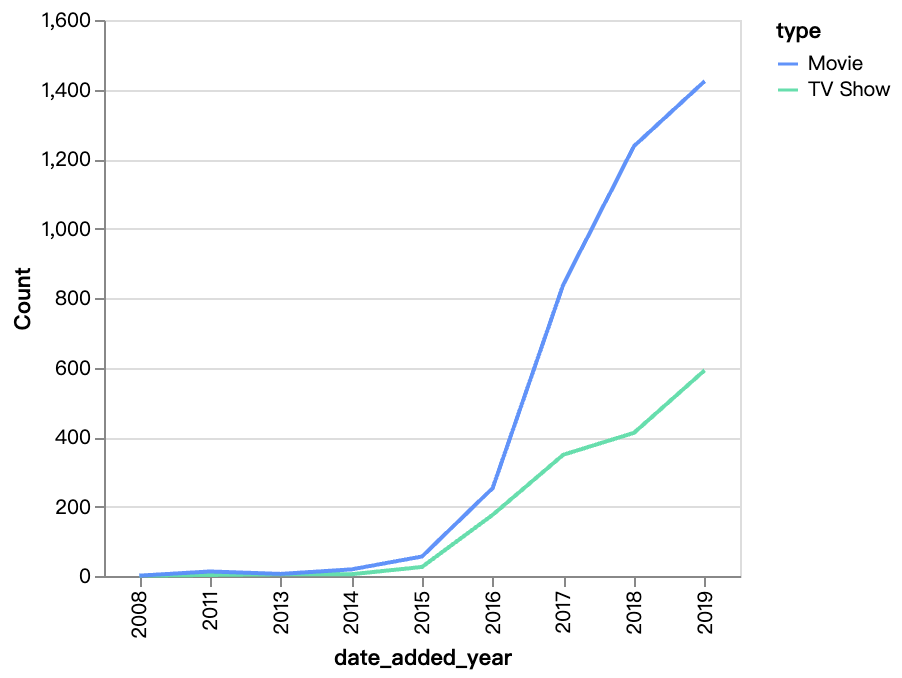


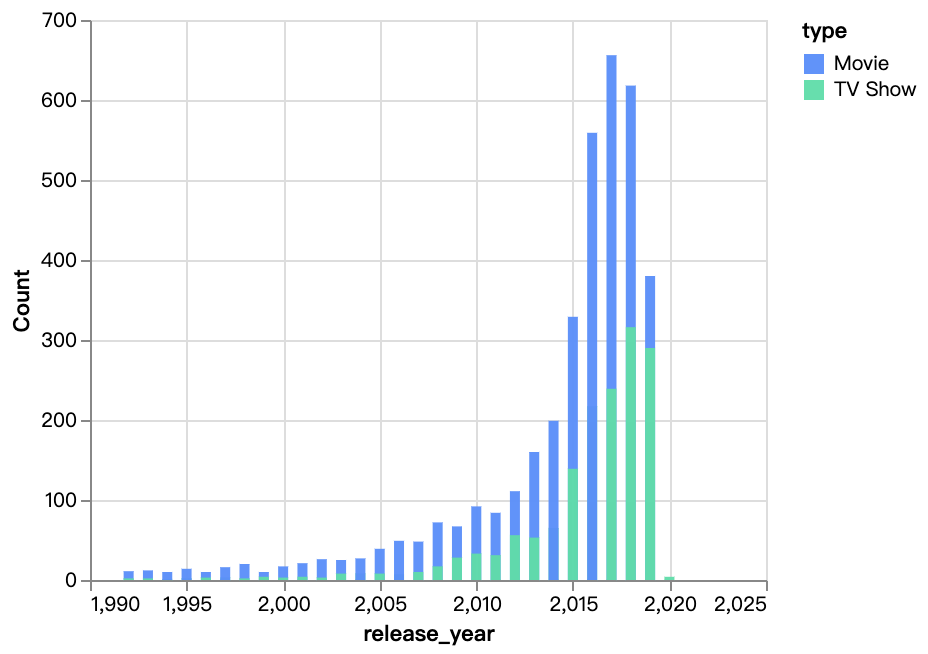


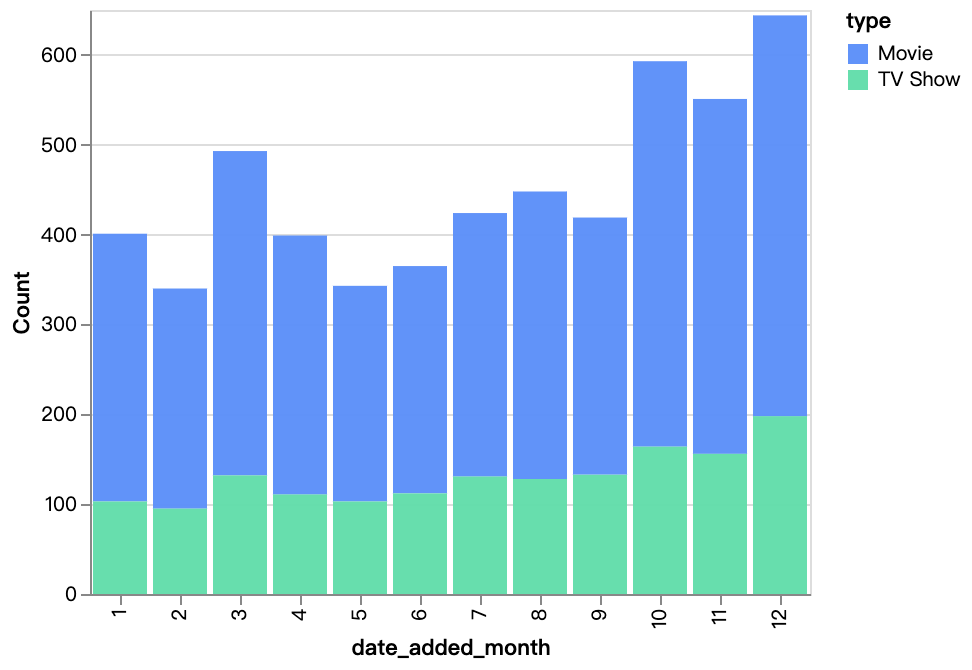

In [7]:
walker0.display_chart("Chart 2", title="Content Added Over Year", desc="The number of movies on Netflix is growing much faster than TV shows, movie content has grown substantially after 2016.")
walker0.display_chart("Chart 3", title="Content Release Over Year")
walker0.display_chart("Chart 4", title="Content Added Over Month", desc="")


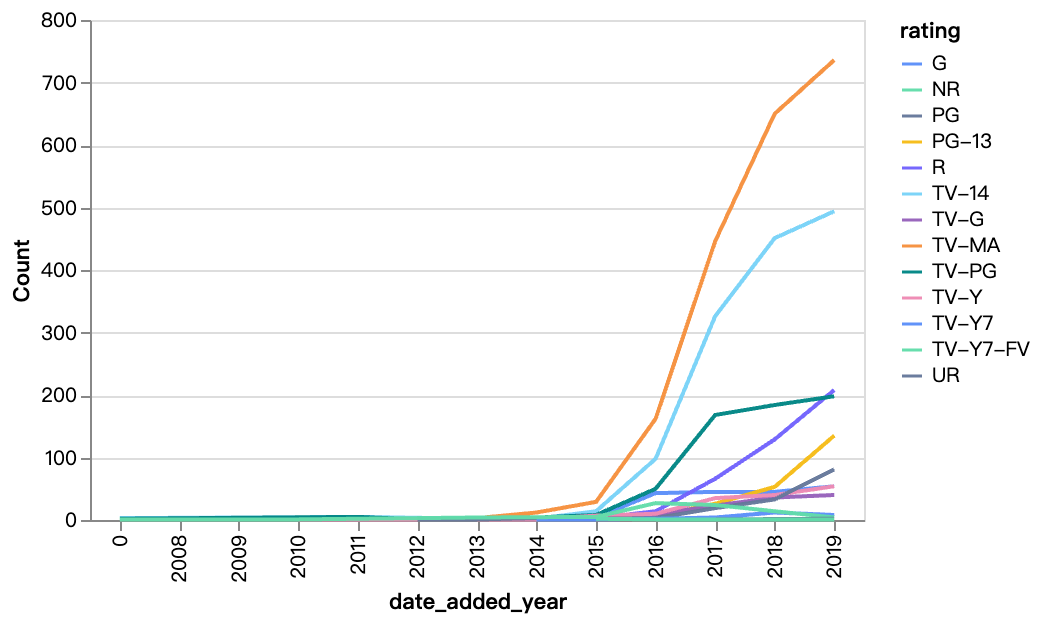

In [8]:
walker0.display_chart("Chart 5", title="Content Added Over Year Diff By Rating", desc="TV-MA, TV-14 are the ratings for most of Netflix's content, and R content is also increasing year by year")


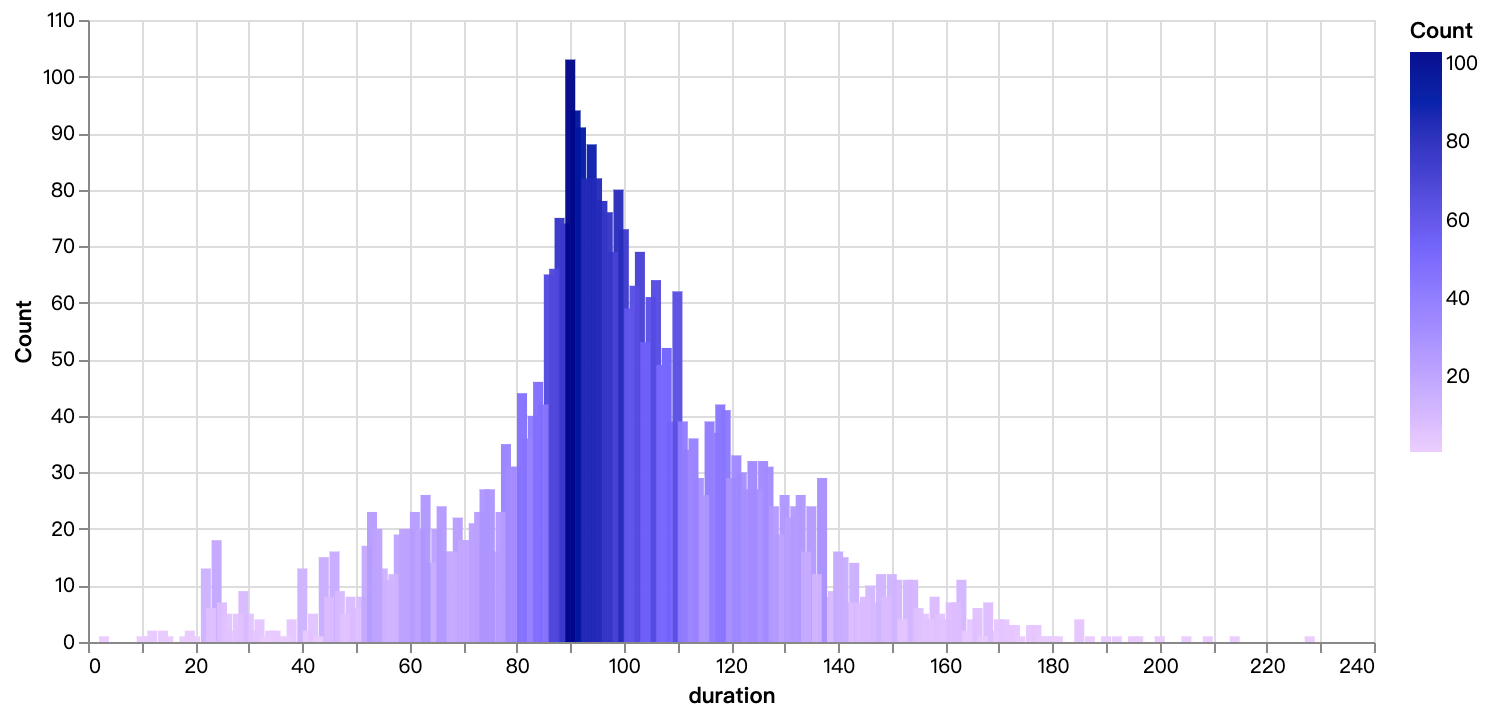

In [9]:
walker0.display_chart("Chart 6", title="movie time distribution", desc="Mainly concentrated between 90 and 110 minutes")


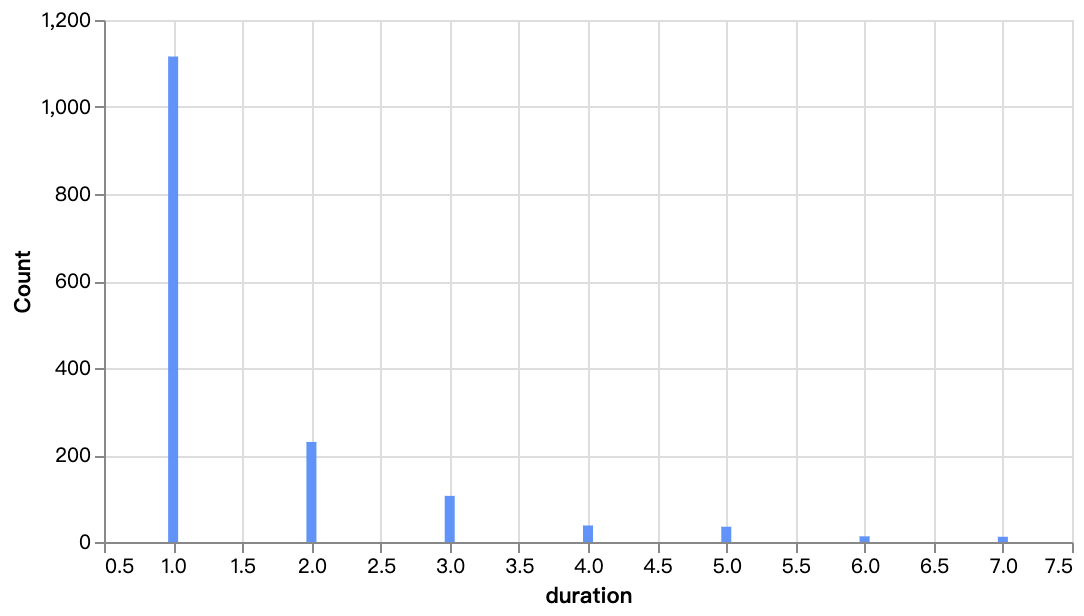

In [10]:
walker0.display_chart("Chart 7", title="tv-show season distribution")

### 2. Country-specific Analysis

In this segment, we're breaking down the content by country. By splitting and restructuring the country column, we can analyze the distribution of content across different countries.

Box(children=(HTML(value='<div id="ifr-pyg-1" style="height: auto">\n    <head>\n        <meta http-equiv="Con…


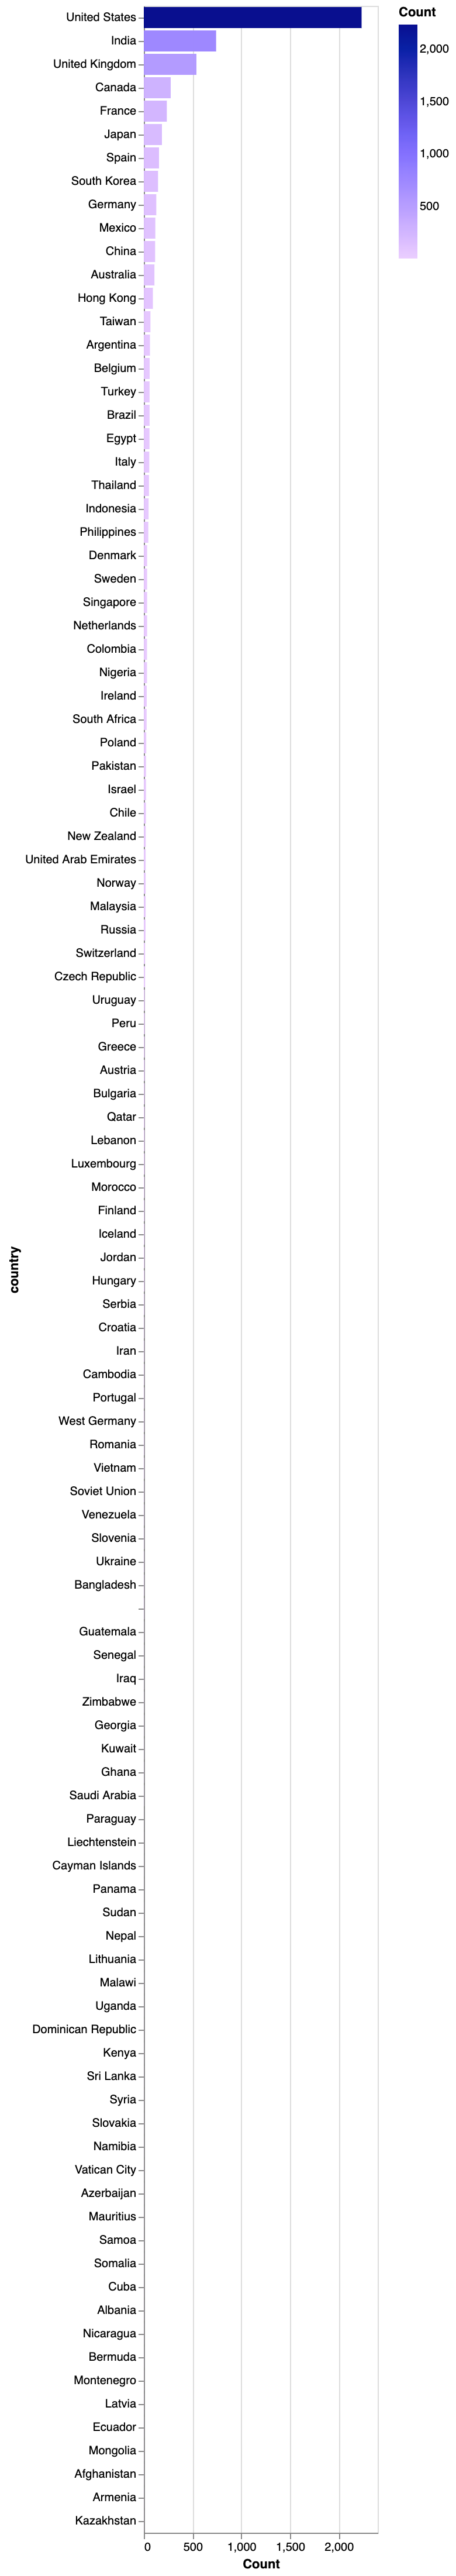

In [11]:
country_df = df["country"].str.split(",", expand=True).stack().reset_index(level=1, drop=True).to_frame('country')
country_df["country"] = country_df["country"].str.strip()
walker1 = pyg.walk(country_df, spec="1.json", use_preview=True)


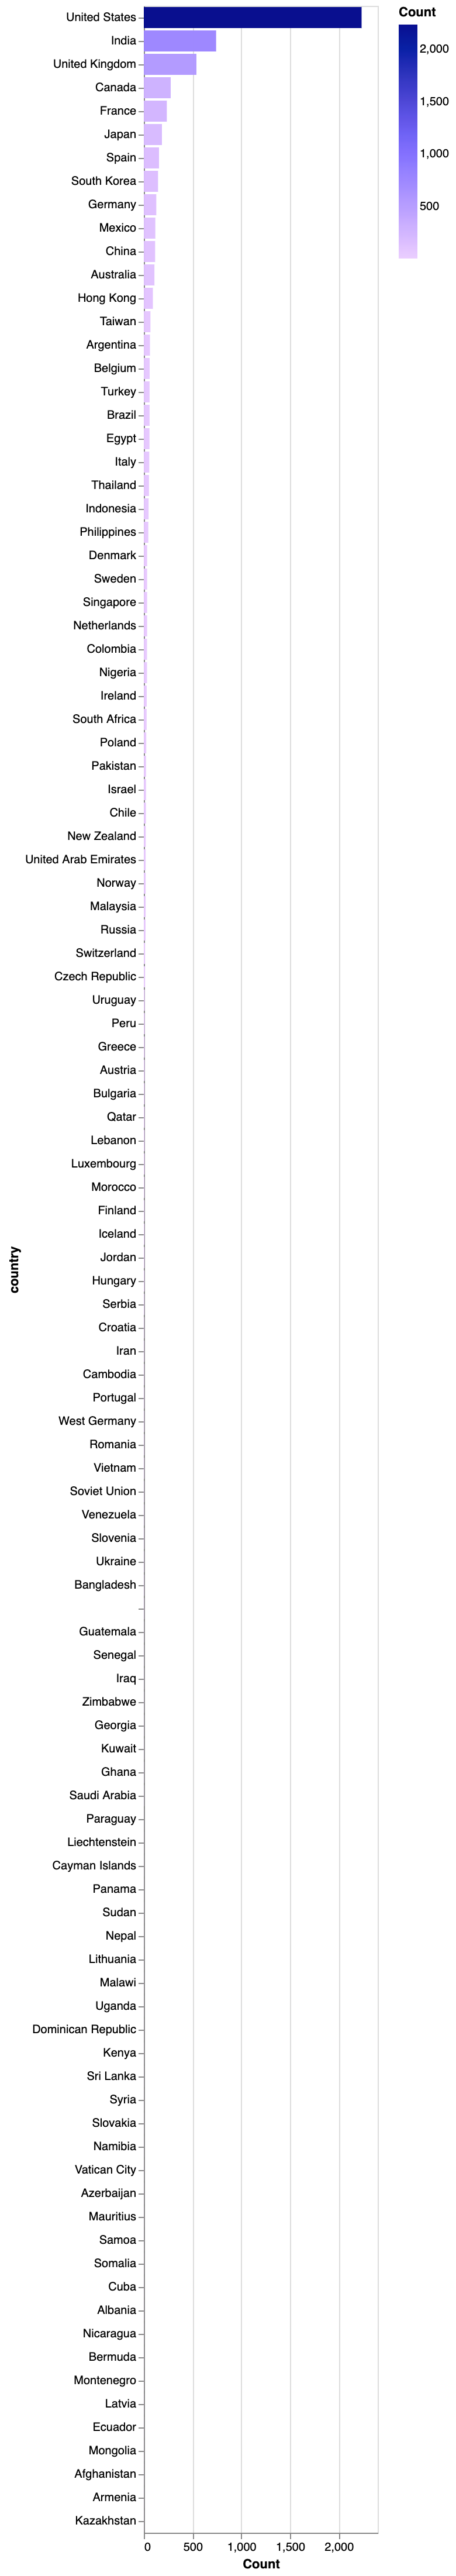

In [13]:
walker1.display_chart("Chart 1", title="Countries Of Most Content")

### 3. Category and Rating Analysis

Lastly, we're focusing on categories and ratings. This section will allow us to understand the distribution of content across genres and how ratings vary within those genres.

Box(children=(HTML(value='<div id="ifr-pyg-2" style="height: auto">\n    <head>\n        <meta http-equiv="Con…


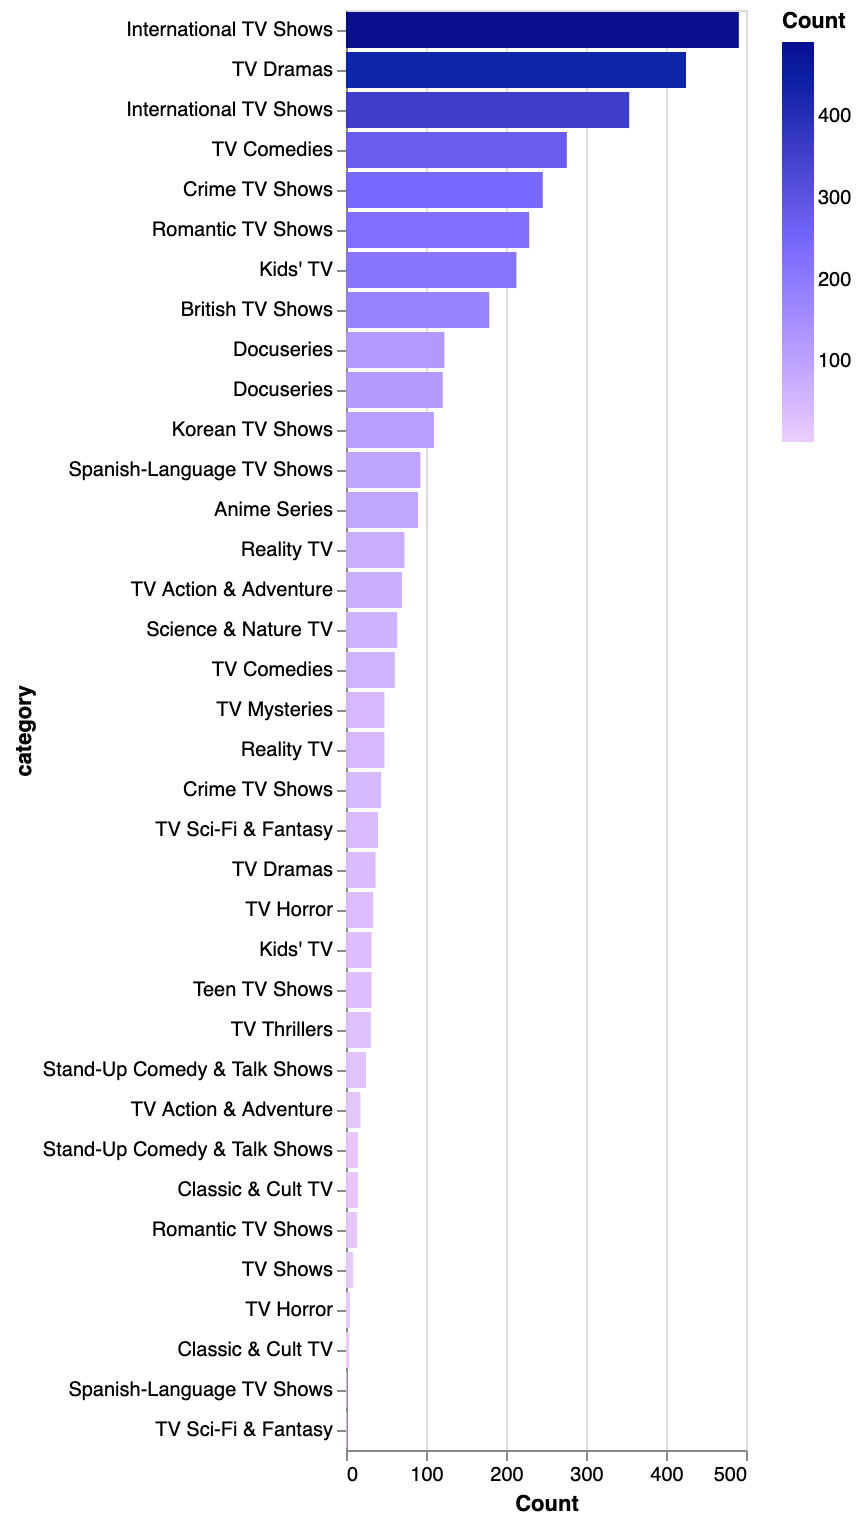
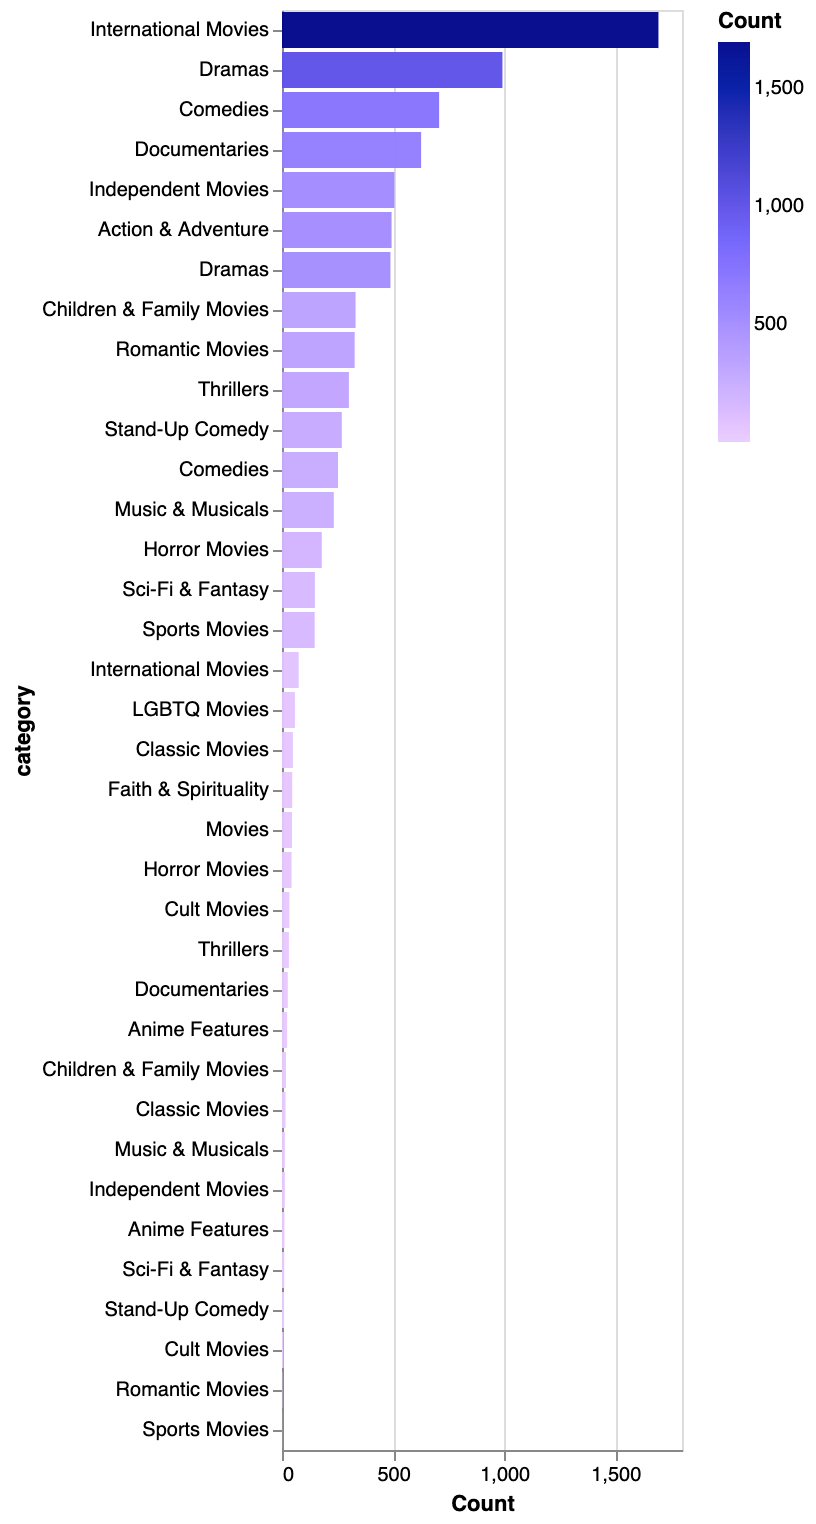
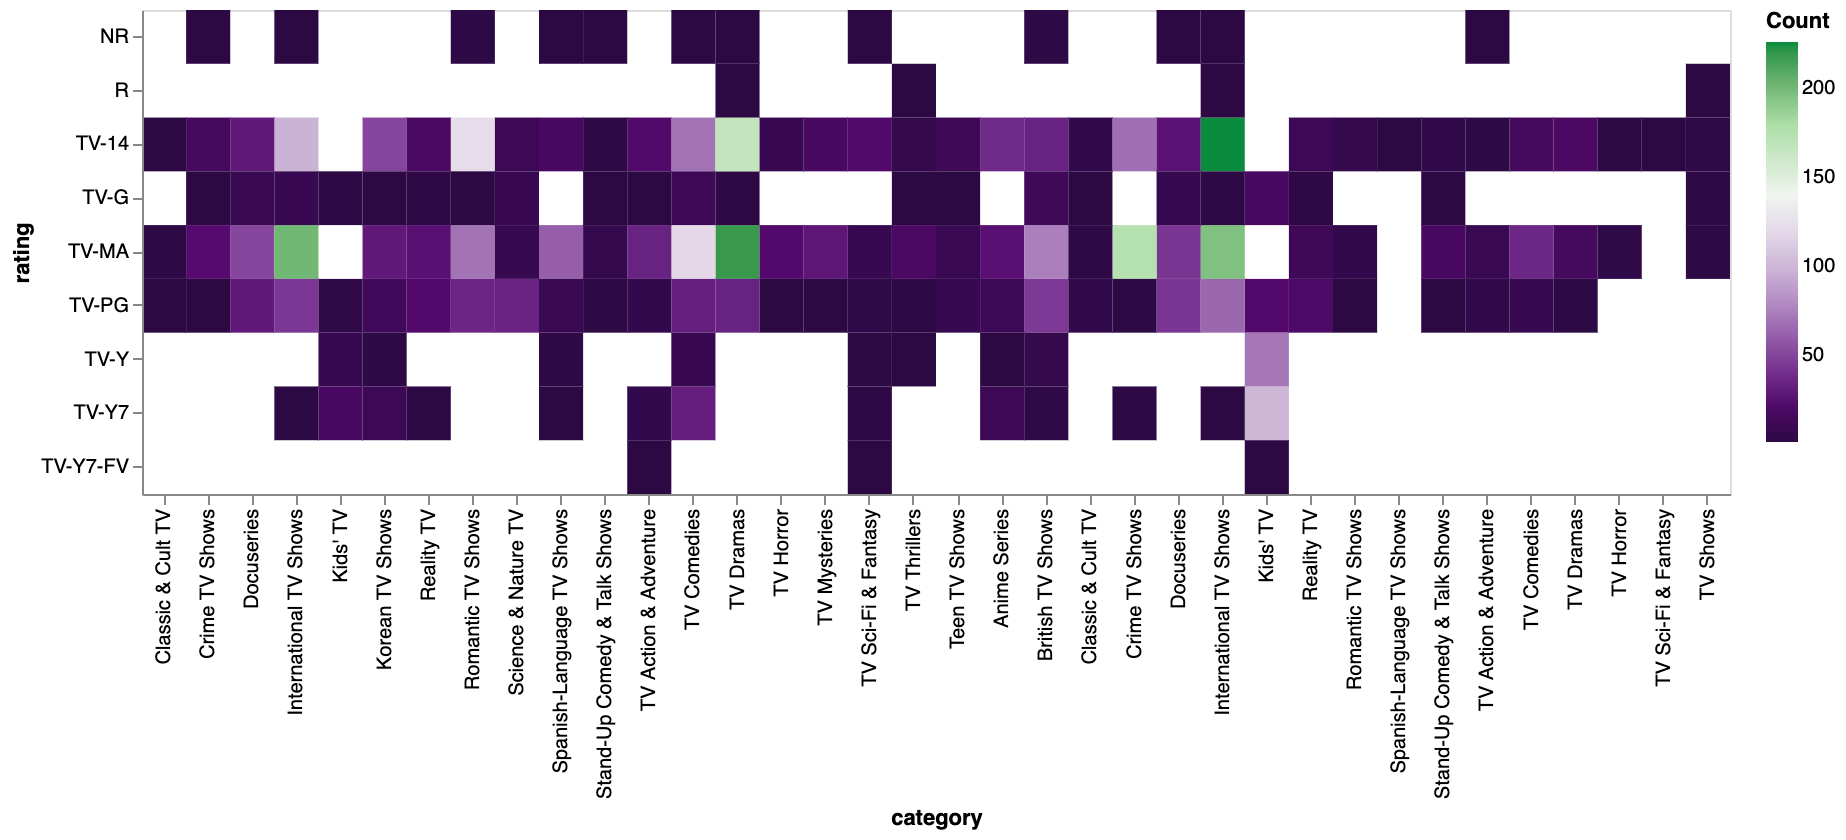
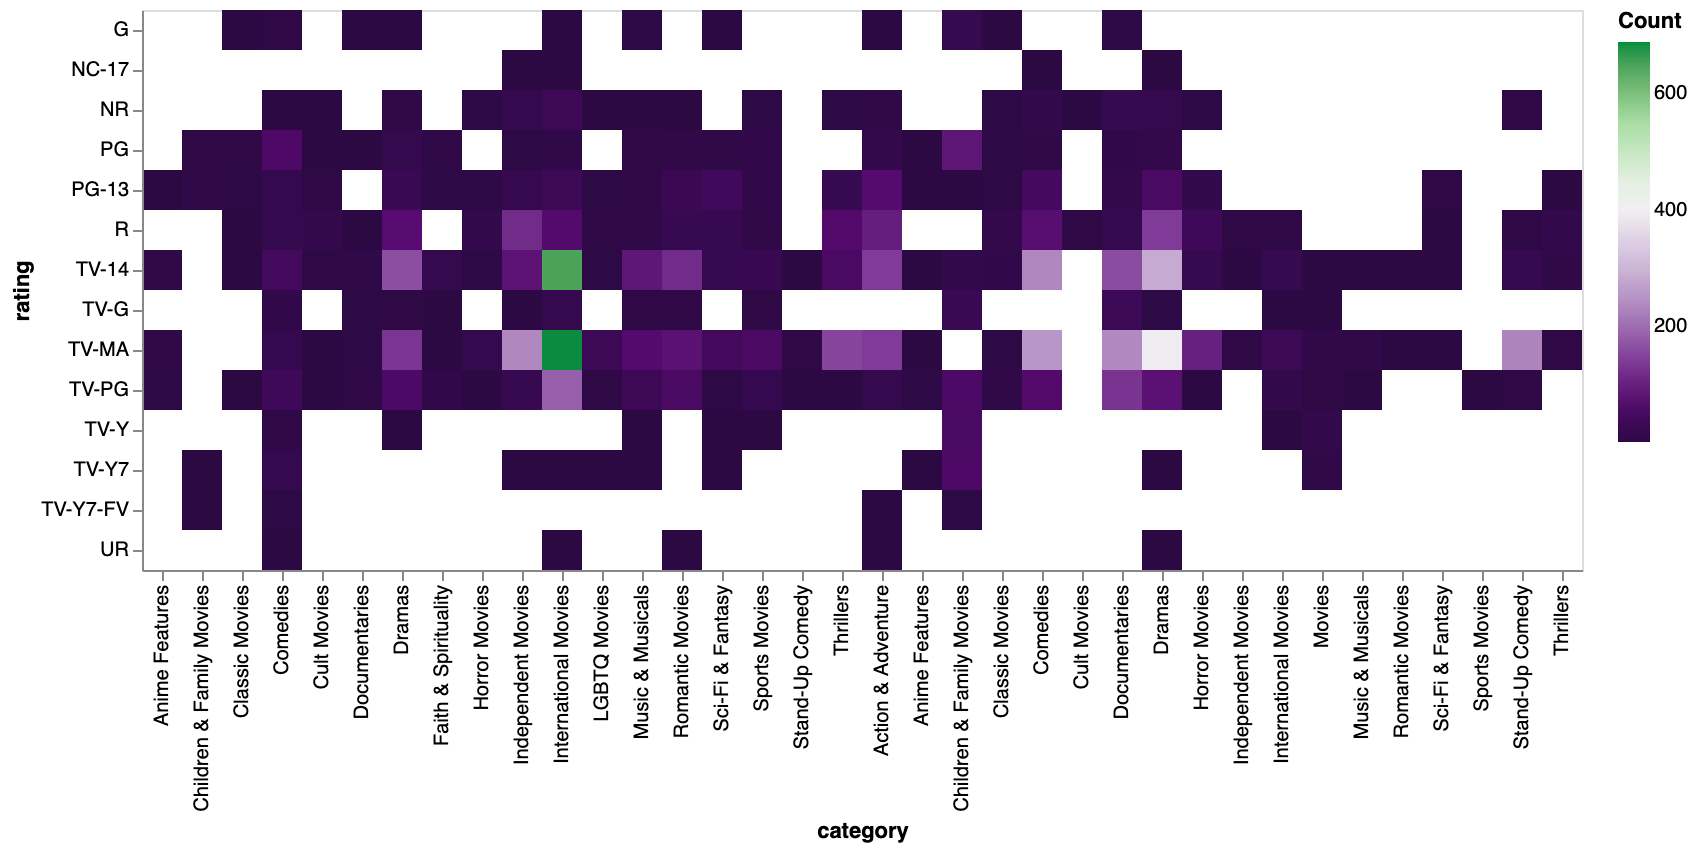

In [14]:
category_df = df.loc[:, ("listed_in", "rating", "type")]
category_df["category"] = category_df["listed_in"].str.split(",")
category_df = category_df[["category", "rating", "type"]]
category_df = category_df.explode("category").reset_index(drop=True)
walker2 = pyg.walk(category_df, spec="2.json", use_preview=True)


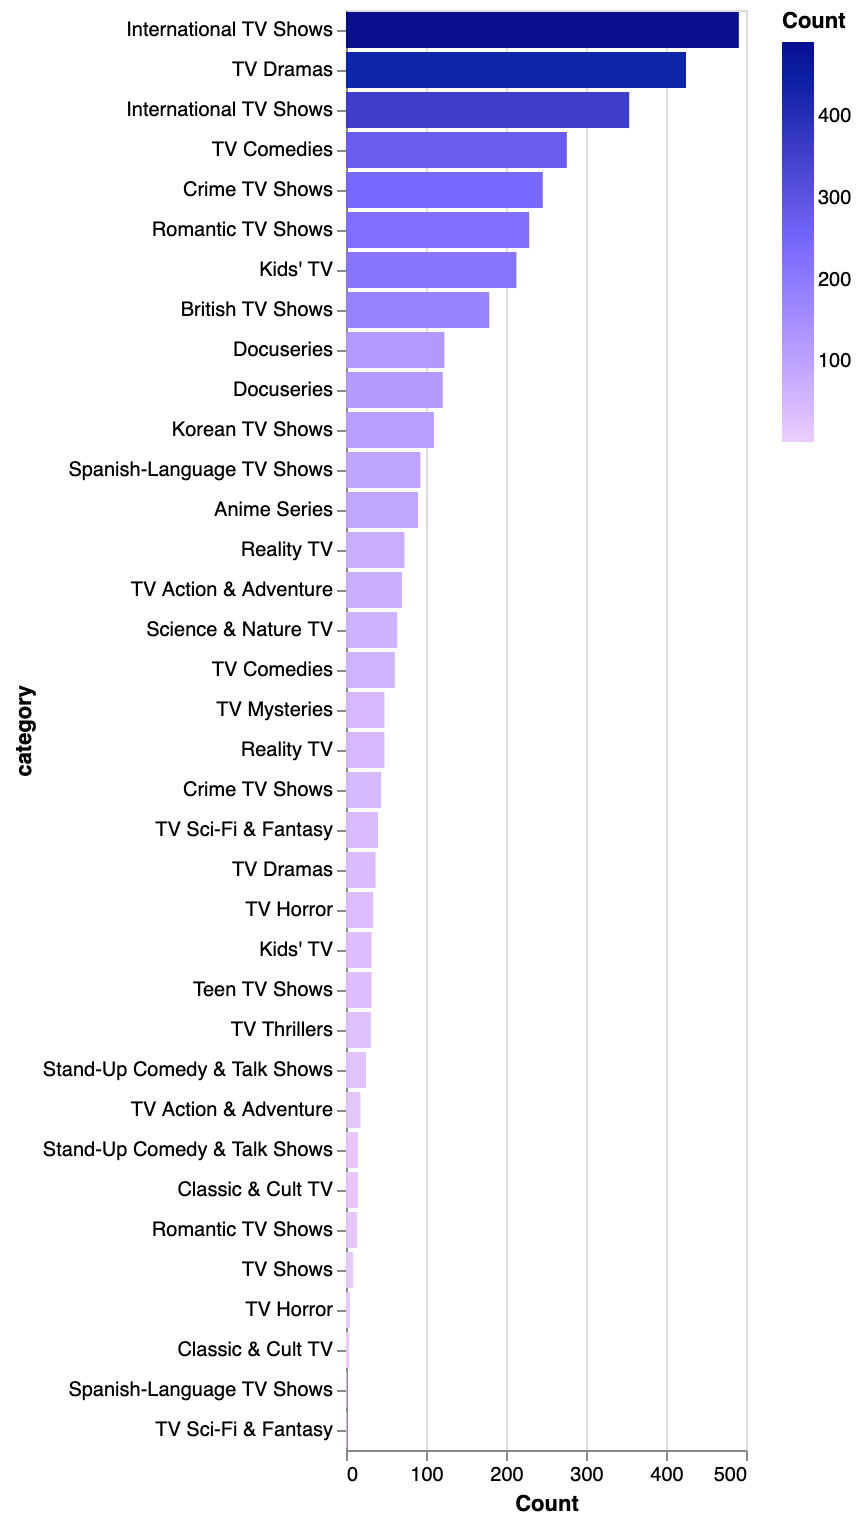

In [17]:
walker2.display_chart("TV category", title="tv-show category distribution")


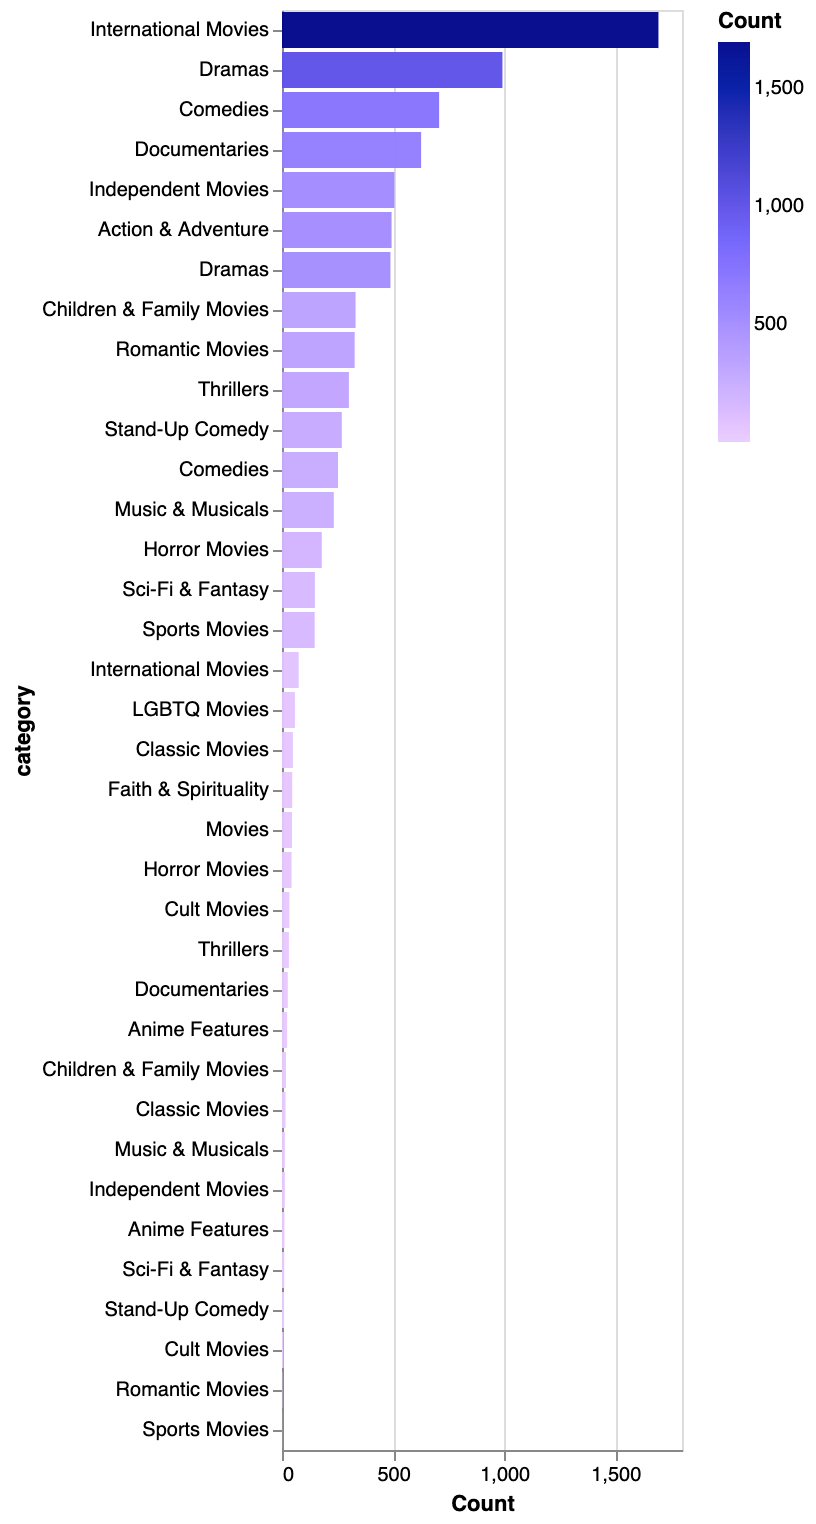

In [18]:
walker2.display_chart("Movie category", title="movie category distribution")


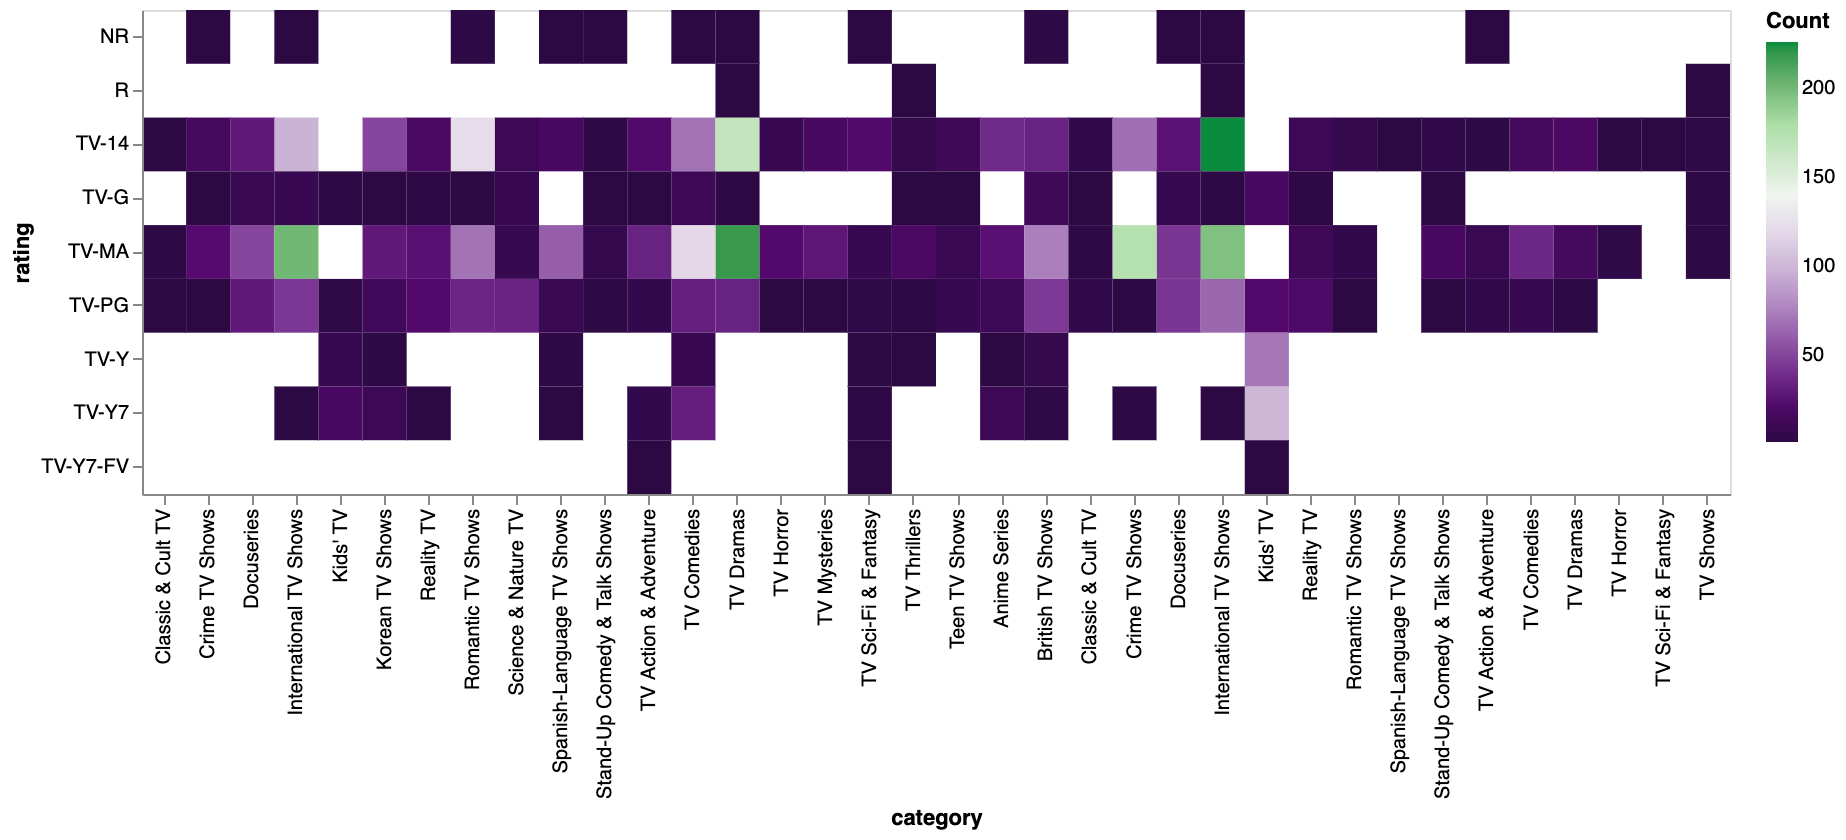

In [19]:
walker2.display_chart("rating category(tv)", title="rating category heatamp(TV-Show)")


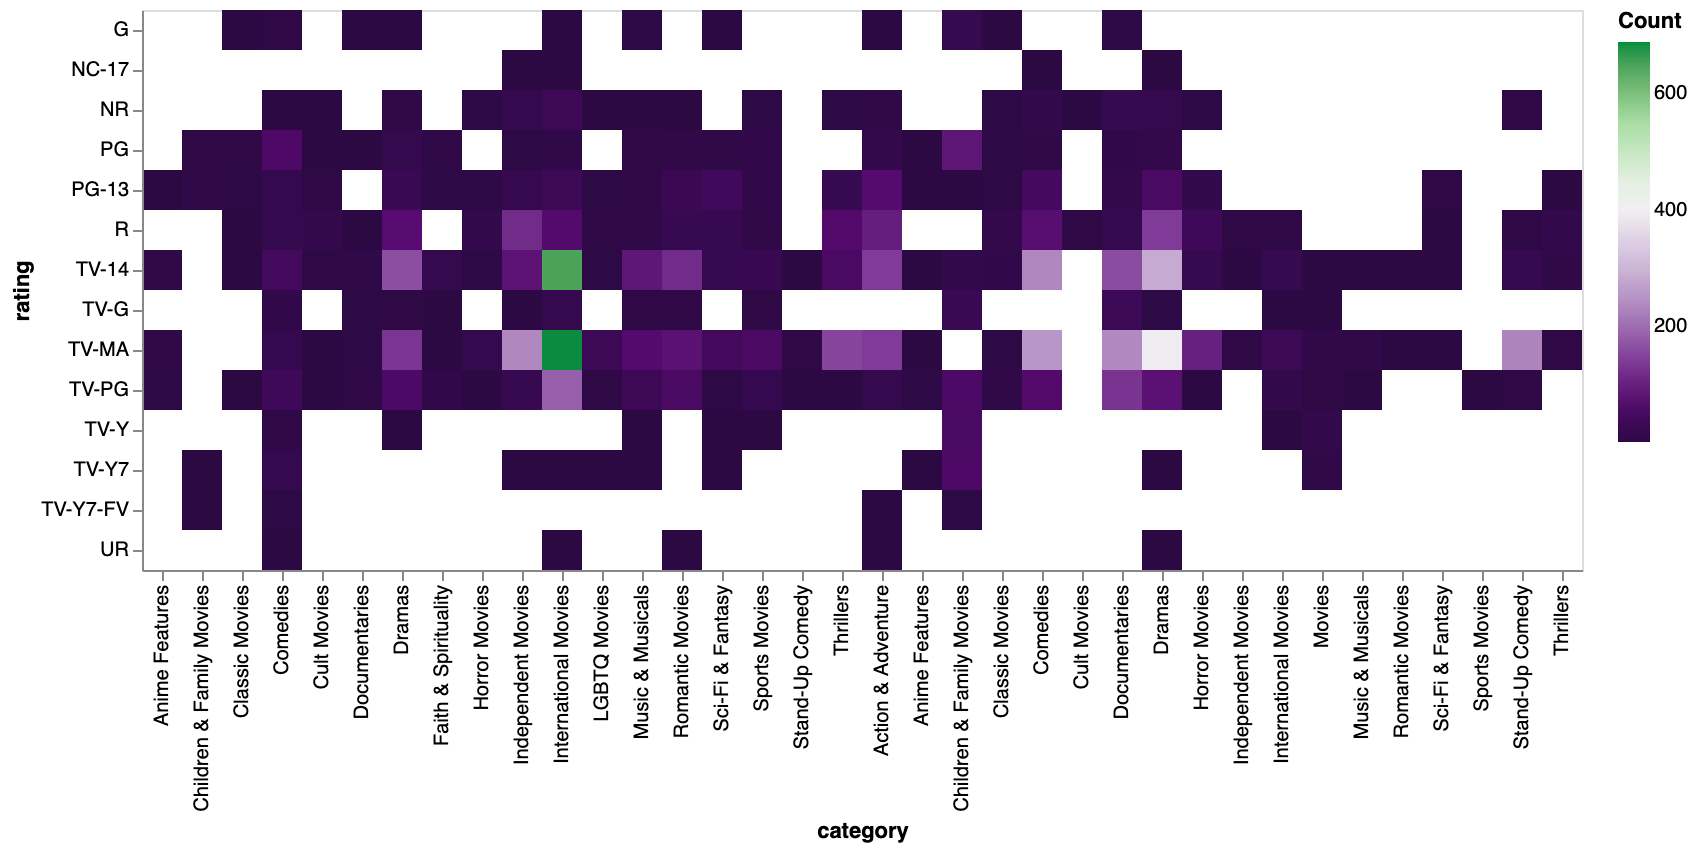

In [20]:
walker2.display_chart("rating category(movie)", title="rating category heatamp(movie)")